# [1교시]

## [예제1]

- 손실의 기울기를 이용한 경사하강법

In [90]:
x, y = 2, 4
w = 1
lr = 0.1

yhat = w * x          # yhat = 1 * 2  -> 2
loss = (y - yhat) ** 2

# 기울기: dL/dw = 2*(yhat - y)*x
grad = 2 * (yhat - y) * x

# 가중치 업데이트
w_new = w - lr * grad

print("yhat =", yhat)
print("loss =", loss)
print("grad =", grad)
print("w_new =", w_new)

yhat = 2
loss = 4
grad = -8
w_new = 1.8


In [ ]:
w = 1.8

# yhat = 1.8 * 2 = 3.6
# 손실 L = (4-3.6)**2 = 0.16


# dl/dw = -2*2(y-1.8*2) = 1.6
w = 1.8 - 0.1 * (- 1.6)

In [ ]:
w

In [ ]:
# y = wx
x , y = 2,4
w = 1
lr = 0.1

predict = w*x
L = (y - predict)**2
print(f'step1 w: {w}, loss: {L}')
gradient = -2*x*(y - predict)
w = w - lr*gradient
print(f'step1 new w: {w}, gradient: {gradient}')

predict = w*x
L = (y - predict)**2
print(f'step2 w: {w}, loss: {L}')
gradient = -2*x*(y - predict)
w = w - lr*gradient
print(f'step2 new w: {w}, gradient: {gradient}')

predict = w*x
L = (y - predict)**2
print(f'step3 w: {w}, loss: {L}')
gradient = -2*x*(y - predict)
w = w - lr*gradient
print(f'step3 new w: {w}, gradient: {gradient}')

In [ ]:
# y = wx
import numpy as np
x , y = 2,4
w = np.random.rand()
lr = 0.01
epochs = 10

for epoch in range(epochs):
    predict = w*x
    L = (y - predict)**2
    print(f'step{epoch + 1} w: {w}, loss: {L}')
    gradient = -2*x*(y - predict)
    w = w - lr*gradient
    print(f'step{epoch + 1} new w: {w}, gradient: {gradient}\n')

In [ ]:
# 경사하강법

x = 2
y = w*x
print(f'predict: {y}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 설정 (재현성 확보)
np.random.seed(42)
x, y = 2.0, 4.0
w = np.random.rand()
lr = 0.1
epochs = 10

# 기록용 리스트
ws = []
preds = []
losses = []
gradients = []

for epoch in range(1, epochs + 1):
    predict = w * x
    loss = (y - predict) ** 2
    gradient = -2 * x * (y - predict)

    # 기록
    ws.append(w)
    preds.append(predict)
    losses.append(loss)
    gradients.append(gradient)

    # 콘솔 출력
    print(f"epoch {epoch:2d}: w={w:.6f}, predict={predict:.6f}, loss={loss:.6f}, gradient={gradient:.6f}")

    # 파라미터 업데이트
    w = w - lr * gradient

# 마지막 상태도 기록 (업데이트 후 최종값)
ws.append(w)
predict = w * x
preds.append(predict)
losses.append((y - predict) ** 2)

# 시각화: 1x3 서브플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1) w 값의 변화
epochs_axis = list(range(0, len(ws)))  # 0..epochs
axes[0].plot(epochs_axis, ws, marker='o', color='tab:blue', label='w')
axes[0].scatter(epochs_axis[0], ws[0], color='green', s=60, label='start')
axes[0].scatter(epochs_axis[-1], ws[-1], color='red', s=60, label='end')
axes[0].annotate(f"{ws[0]:.3f}", (epochs_axis[0], ws[0]), textcoords="offset points", xytext=(0,8), ha='center')
axes[0].annotate(f"{ws[-1]:.3f}", (epochs_axis[-1], ws[-1]), textcoords="offset points", xytext=(0,8), ha='center')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('w')
axes[0].set_title('w over epochs')
axes[0].legend()
axes[0].grid(True)

# 2) Loss 변화 (로그 스케일)
axes[1].plot(epochs_axis, losses, marker='o', color='tab:orange', label='loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over epochs (log scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, which='both', ls='--')

# 3) 파라미터 경로 (w vs Loss)
axes[2].plot(ws, losses, marker='o', color='tab:purple', label='path')
axes[2].scatter(ws[0], losses[0], color='green', s=60, label='start')
axes[2].scatter(ws[-1], losses[-1], color='red', s=60, label='end')
axes[2].annotate("start", (ws[0], losses[0]), textcoords="offset points", xytext=(5,5))
axes[2].annotate("end", (ws[-1], losses[-1]), textcoords="offset points", xytext=(5,5))
axes[2].set_xlabel('w')
axes[2].set_ylabel('Loss')
axes[2].set_title('Parameter path (w vs Loss)')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
output_filename = 'gradient_descent.png'
plt.savefig(output_filename, dpi=150)
print(f'Figure saved to: {output_filename}')


## 1. 가중치 𝑤 변화 (왼쪽 그래프)
- 초기값은 약 𝑤 ≈ 0.375 에서 시작.
- 학습 초반에 빠르게 증가하여 𝑤 ≈ 2.0 근처에서 안정화.
- 이는 경사하강법이 빠르게 최적값에 수렴하고 있음을 보여주고 있다.

## 2. 손실(Loss) 변화 (가운데 그래프, 로그 스케일)
- 손실 값이 지수적으로 감소하는 모습을 확인할 수 있다.
- 로그 스케일에서 직선에 가까운 형태로 떨어지는 것은 지속적이고 안정적인 학습을 의미한다.
- 최종적으로 손실이 10 − 12  수준까지 줄어들어, 모델이 목표값을 거의 완벽하게 맞추고 있음을 알 수 있다.

## 3. 파라미터 경로 (오른쪽 그래프, w vs Loss)
- 시작점은 𝑤 ≈ 0.375, 𝐿 ≈ 10 부근.
- 학습이 진행되면서 오른쪽으로 이동(가중치 증가)하고 동시에 아래로 이동(손실 감소)하는 궤적을 그린다.
- 최종적으로 𝑤 ≈ 2.0, 𝐿 ≈ 0에 도달하여 최적화가 성공적으로 이루어진 과정을 시각적으로 보여준다.

## [예제2]

In [ ]:
# 사과 가격 : 100원
# 사과 개수 : 2개
# 소비세 : 1.1
# z = (100*2)* 1.1

# 순전파(앞으로 계산)
# a = 100 * 2 = 200
# z = a * 1.1 = 220
 
# 최종금액이 1원 변할 때, 사과 가격은 얼마나 변할까?

- 체인룰

$$
\frac{\alpha_{z}}{\alpha_{100}} =
\frac{\alpha_{z}}{\alpha_{a}}
\frac{\alpha_{a}}{\alpha_{100}}
$$

- 계산

- $
\frac{\alpha_{z}}{\alpha_{a}}\ = 1.1 (세금 곱하기)
$

- $
\frac{\alpha_{a}}{\alpha_{100}} = 2(개수 2개 곱하기)
$

- 따라서
$
\frac{\alpha_{z}}{\alpha_{100}} = 1.1 X 2 = 2.2
$

In [ ]:
200*1.1

# [2교시]

## 체인룰(연쇄법칙) 과정

In [ ]:
# 출력까지 여러 연산으로 이루어져 있음

# 각각에 대해서 기울기를 통해 연쇄법칙이 이루어진다
# 각 구간의 로컬변화율(미분)을 곱해서
# 최종적으로 DL / DW 구함

# 체인룰 : 출력오차가 앞단 가중치까지 어떻게 전파되는지 계산하는 규칙
# 이 값으로 w - lr *gradient 업데이트 수행

# 신경망(은닉층 1개, 출력층 1개) --> 체이닝 룰
# 입력 x 
# 은닉층 z1 = wx + b1, h = relu(z1)
# 출력층 z2 = w2h + b2, yhat = sigmoid(z2)
# 손실 L 1/2(y- yhat)**2

# [출력층 미분]

$$
\frac{\alpha_{L}}{\alpha_{W2}} =
\frac{\alpha_{L}}{\alpha_{\hat{y}}}
\cdot
\frac{\alpha_{\hat{y}}}{\alpha_{2}}
\cdot
\frac{\alpha_{z2}}{\alpha_{w2}}
$$


# [신경망 (은닉층 1개, 출력층 1개)]

## 입력: $x$
---
## 은닉층:
$$
z_1 = w x + b_1, \quad h = \text{ReLU}(z_1)
$$
---
## 출력층:
$$
z_2 = w_2 h + b_2, \quad \hat{y} = \sigma(z_2)
$$
---
## 손실 함수:
$$
L = \tfrac{1}{2}(y - \hat{y})^2
$$
---
## 체인룰 (연쇄법칙)

## 최종적으로 $\frac{\partial L}{\partial w}$ 를 구하기 위해 각 구간의 로컬 변화율을 곱합니다:

$$
\frac{\partial L}{\partial w}
= \frac{\partial L}{\partial \hat{y}}
\cdot \frac{\partial \hat{y}}{\partial z_2}
\cdot \frac{\partial z_2}{\partial h}
\cdot \frac{\partial h}{\partial z_1}
\cdot \frac{\partial z_1}{\partial w}
$$
---
## 가중치 업데이트 규칙

$$
w \leftarrow w - \text{lr} \cdot \frac{\partial L}{\partial w}
$$


# [출력층에서의 미분]
---
## 1. 손실에 대한 $\hat{y}$의 미분:
$$
\frac{\partial L}{\partial \hat{y}} = -(y - \hat{y})
$$
---
## 2. $\hat{y}$에 대한 $z_2$의 미분 (시그모이드 도함수):
$$
\frac{\partial \hat{y}}{\partial z_2} = \hat{y}(1 - \hat{y})
$$
---
## 3. 따라서 출력층에서의 국소 기울기:
$$
\frac{\partial L}{\partial z_2} =
\frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2}
= -(y - \hat{y}) \cdot \hat{y}(1 - \hat{y})
$$
---
## 4. 출력층 가중치 $w_2$에 대한 미분:
$$
\frac{\partial L}{\partial w_2} =
\frac{\partial L}{\partial z_2} \cdot \frac{\partial z_2}{\partial w_2}
= \big( -(y - \hat{y}) \cdot \hat{y}(1 - \hat{y}) \big) \cdot h
$$


In [ ]:
import torch 
import matplotlib.pyplot as plt
torch.manual_seed(42)

In [ ]:
# 기울기
# f(x) = x^2 f'(x) = 2x

h_value = [1.0, 0.5, 0.1, 0.01, 0.001]

x0 = 3.0
f_prime = 2*x0

for h in h_value:
    gradient = ((x0+h)**2 - x0**2) / h
    print(f'두 점의 기울기 : {gradient}')

print(f'이론상 접선 기울기 : {x*x0}')

In [ ]:
# 과일예제를 체인룰 코드로 증명
# z = (사과 가격 X 개수) X 세율

# DZ / D사과가격 = 개수 X 세율

import torch
apple_price = torch.tensor(100.0, requires_grad=True)
apple_count = 2.0
tax = 1.1

subtotal = apple_price * apple_count
total_price = subtotal * tax

total_price.backward()

manual_gradient = apple_count * tax
auto_gradient = apple_price.grad.item()

print(manual_gradient, auto_gradient)

# [3교시]

In [ ]:
# f(x) = x^2    ---> 손실함수
x_manual = 4.0 # 시작점
lr = 0.1
manual_history = [x_manual]

for step in range(20):
    gradient = 2 * x_manual         # loss의 backward 역할
    x_manual = x_manual - lr*gradient
    manual_history.append(x_manual)
    if step< 8 or step >= 18:
        print(f'step {step+1} : x={x_manual:.4f} 기울기 = {gradient:.4f} f(x) = {x_manual**2:.4f}')
    elif step == 8:
        print('------ 중간생략 ------')
    print(f'최종도달위치 : x = {x_manual:.6f} (목표 0.0)')


In [ ]:
import torch
x_pt = torch.tensor([4.0], requires_grad=True)
optimizer = torch.optim.SGD([x_pt], lr=0.1)
pt_history = [x_pt.item()]

for step in range(20):
    optimizer.zero_grad()
    loss = x_pt**2
    loss.backward()     # 자동 미분 : 각 계산 구간별 기울기를 자동으로 구함
    optimizer.step()
    pt_history.append(x_pt.item())
    if step < 3:
        print(f'step {step+1} : x={x_pt.item():.4f} 자동 계산된 기울기 = {x_pt.grad.item():.4f}, f(x) = {x_pt.grad.item()**2:.4f}')


In [ ]:
pt_history

In [ ]:
# 학습률
import matplotlib.pyplot as plt
learning_rate = [0.01, 0.1, 0.9]
colors = ['blue', 'green', 'red']
labels = ['lr=0.01(too slow)', 'lr=0.1(good))', 'lr=0.9(bad)']

fig, ax = plt.subplots(figsize=(12, 5))
for lr_val, color, label in zip(learning_rate, colors, labels):
    x_test = 4.0
    history = [x_test]
    for i in range(30):
        grad = 2*x_test
        x_test = x_test - lr_val*grad
        history.append(x_test)
    ax.plot(history, marker='o', markersize=3, color=color, label=label)
plt.legend()
plt.tight_layout()
plt.show()

# [4교시]

In [ ]:
# 은닉층 1개 + 출력층 1개 : 체인룰 -> backward
# z1 = w1x + b1 h = activation(z1)

import torch
def sigmoid(v):
    return 1/(1+torch.exp(-v))

In [ ]:
# 샘플 1개 초기파라메터
x = 1.5
y = 1.0
w1, b1 = 0.5, -0.4
w2, b2 = -1.2, 0.3
lr = 0.1

# 순전파(수동)
z1 = w1 * x + b1
h = 1/(1+torch.exp(torch.tensor(-z1))).item()
z2 = w2 * h + b2
y_hat = 1/(1+torch.exp(torch.tensor(-z2))).item()
loss = 0.5*(y-y_hat)**2

# 체인룰 미분(수동) (=backward)
dL_dyhat = (y_hat - y)
dyhat_dz2 = y_hat*(1-y_hat)
dL_dz2 = dL_dyhat*dyhat_dz2

dL_dw2_manual = dL_dz2*h
dL_db2_manual = dL_dz2

dL_dh = dL_dz2*w2
dh_dz1 = h*(1-h)
dL_dz1 = dL_dh*dh_dz1

dL_dw1_manual = dL_dz1*x
dL_db1_manual = dL_dz1

print(f'dL/dw1 = {dL_dw1_manual} dL/db1 = {dL_db1_manual}')
print(f'dL/dw2 = {dL_dw2_manual} dL/db2 = {dL_db2_manual}')

In [ ]:
# autograd
x_t = torch.tensor([x], dtype=torch.float32)
y_t = torch.tensor([y], dtype=torch.float32)
w1_t = torch.tensor([w1], dtype=torch.float32, requires_grad=True)
b1_t = torch.tensor([b1], dtype=torch.float32, requires_grad=True)
w2_t = torch.tensor([w2], dtype=torch.float32, requires_grad=True)
b2_t = torch.tensor([b2], dtype=torch.float32, requires_grad=True)

h_t = sigmoid(w1_t*x + b1_t)
yhat_t = sigmoid(w2_t * h_t + b2_t)
loss_t = 0.5*(yhat_t - y_t)**2
loss_t.backward()

print(f'dL/dw1 = {w1_t.grad.item()} dL/db1 = {b1_t.grad.item()}')
print(f'dL/dw2 = {w2_t.grad.item()} dL/db2 = {b2_t.grad.item()}')

abs(dL_dw1_manual - w1_t.grad.item()), abs(dL_db1_manual - b1_t.grad.item())

In [ ]:
# 경사하강법
with torch.no_grad():
    w1_new = w1_t - lr*w1_t.grad
    b1_new = b1_t - lr*b1_t.grad
    w2_new = w2_t - lr*w2_t.grad
    b2_new = b2_t - lr*b2_t.grad

    h_new = sigmoid(w1_new*x_t+b1_new)
    yhat_new = sigmoid(w2_new * h_new + b2_new)
    loss_new = 0.5*(yhat_new-y_t)**2

    print(f'업데이트전 loss : {loss_t.item()}')
    print(f'업데이트후 loss : {loss_new.item()}')

# [5교시]

In [ ]:
class Chain_Test:
    def __init__(self):
        self.year = 0
        self.nonth = 0
        self.day = 0
    def setyear(self, year):
        self.year = year
        return self
    def setmonth(self, month):
        self.month = month
        return self
    def setday(self, day):
        self.day = day
        return self

chain = Chain_Test()
chain.setyear('2026').setmonth('04').setday('22')

# [6교시]

In [59]:
import seaborn as sns
titanic = sns.load_dataset('titanic')
# 학습용데이터 정답을 분리
# 훈련 검증 테스트 데이터 분리
# pytorch로 신경망 구성
# 손실함수는 BCEloss
# optimizer adam lr=기본값
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [60]:
y = titanic['survived'].to_numpy()
X = titanic.loc[:, 'pclass':]
X.drop('class', axis=1)
X

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [ ]:
titanic = titanic = 

In [87]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

# 수치형 standard....  범주형  onehot
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import torch
titanic = titanic.dropna()
y = titanic['survived'].to_numpy()
X =titanic.loc[:,'pclass':]
X = X.drop(['class','sex','embark_town','alive','deck'], axis=1)

numeric_cols = ['pclass','age','sibsp','parch','fare']
categorical_cols = ['embarked','who','adult_male','alone']
numeric_pipe = Pipeline([
     ('scaler',StandardScaler())
])
categorical_pipe = Pipeline([
    ('onehot', OneHotEncoder())
])

transformer = ColumnTransformer(
    transformers=[
        ('num',numeric_pipe,numeric_cols),
        ('cat',categorical_pipe,categorical_cols)
    ]
)

x_train_full,x_test,y_train_full,y_test = train_test_split(X,y,stratify=y, random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_full, y_train_full, stratify=y_train_full, random_state=42)

x_train = transformer.fit_transform(x_train)
x_val = transformer.transform(x_val)
x_test = transformer.transform(x_test)

In [62]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((102, 15), (102,), (34, 15), (34,))

In [80]:
import torch.nn as nn
class TitanicDNN(nn.Module):
  def __init__(self,input_dim=15):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear( input_dim , 64 ),
        nn.ReLU(),
        nn.Linear(64,1),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.net(x)

model = TitanicDNN()

# [7교시]

In [81]:
x_train_t = torch.tensor( x_train,dtype=torch.float32)
x_val_t = torch.tensor( x_val,dtype=torch.float32)
x_test_t = torch.tensor( x_test,dtype=torch.float32)

y_train_t = torch.tensor( y_train,dtype=torch.float32)
y_val_t = torch.tensor( y_val,dtype=torch.float32)
y_test_t = torch.tensor( y_test,dtype=torch.float32)


In [82]:
y_train_t.shape

torch.Size([102])

In [83]:
model(x_train_t)

tensor([[0.5110],
        [0.5223],
        [0.4641],
        [0.5312],
        [0.5593],
        [0.5116],
        [0.4873],
        [0.5018],
        [0.5763],
        [0.5329],
        [0.5391],
        [0.5401],
        [0.5936],
        [0.5685],
        [0.5867],
        [0.4673],
        [0.5600],
        [0.5591],
        [0.5780],
        [0.5593],
        [0.5295],
        [0.4845],
        [0.5150],
        [0.6096],
        [0.5897],
        [0.4906],
        [0.4723],
        [0.5867],
        [0.5017],
        [0.5536],
        [0.5634],
        [0.6148],
        [0.5623],
        [0.6256],
        [0.5347],
        [0.5200],
        [0.4931],
        [0.5621],
        [0.5029],
        [0.6401],
        [0.5299],
        [0.5768],
        [0.5740],
        [0.5123],
        [0.5487],
        [0.5470],
        [0.5341],
        [0.5663],
        [0.6164],
        [0.4764],
        [0.4514],
        [0.5439],
        [0.5777],
        [0.5364],
        [0.5071],
        [0

In [84]:
print("predict shape should be (N,1). x_train_t.shape:", x_train_t.shape, " y_train_t.shape:", y_train_t.shape)

predict shape should be (N,1). x_train_t.shape: torch.Size([102, 15])  y_train_t.shape: torch.Size([102])


In [85]:
# 손실함수
bce = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 100
train_losses, val_losses = [], []
for epoch in range(epochs):   
  # forward
  predict = model(x_train_t)    
  loss = bce(predict, y_train_t.unsqueeze(1))
  # backward
  loss.backward()
  # 업데이트
  optimizer.step()
  # 가중치초기화
  optimizer.zero_grad()

  # val 으로 epoch 추론
  with torch.no_grad():
    val_output = model(x_val_t)
    val_loss = bce(val_output, y_val_t.unsqueeze(1))    

  print(f'epoch : {epoch+1} loss:{loss.item():.4f} val_loss : {val_loss.item():.4f}')
  train_losses.append(loss.item())
  val_losses.append(val_loss.item())

epoch : 1 loss:0.6908 val_loss : 0.6795
epoch : 2 loss:0.6861 val_loss : 0.6753
epoch : 3 loss:0.6815 val_loss : 0.6712
epoch : 4 loss:0.6769 val_loss : 0.6672
epoch : 5 loss:0.6724 val_loss : 0.6633
epoch : 6 loss:0.6680 val_loss : 0.6594
epoch : 7 loss:0.6637 val_loss : 0.6556
epoch : 8 loss:0.6594 val_loss : 0.6518
epoch : 9 loss:0.6552 val_loss : 0.6481
epoch : 10 loss:0.6511 val_loss : 0.6444
epoch : 11 loss:0.6470 val_loss : 0.6407
epoch : 12 loss:0.6430 val_loss : 0.6371
epoch : 13 loss:0.6390 val_loss : 0.6336
epoch : 14 loss:0.6351 val_loss : 0.6301
epoch : 15 loss:0.6312 val_loss : 0.6267
epoch : 16 loss:0.6274 val_loss : 0.6233
epoch : 17 loss:0.6236 val_loss : 0.6199
epoch : 18 loss:0.6199 val_loss : 0.6167
epoch : 19 loss:0.6162 val_loss : 0.6134
epoch : 20 loss:0.6125 val_loss : 0.6102
epoch : 21 loss:0.6089 val_loss : 0.6070
epoch : 22 loss:0.6053 val_loss : 0.6038
epoch : 23 loss:0.6017 val_loss : 0.6007
epoch : 24 loss:0.5982 val_loss : 0.5977
epoch : 25 loss:0.5947 va

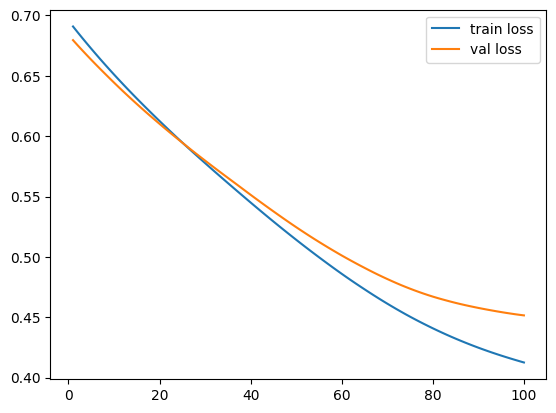

tensor(0.7826)

In [86]:
import matplotlib.pyplot as plt
plt.plot(range(1, epochs+1), train_losses, label = 'train loss')
plt.plot(range(1, epochs+1), val_losses, label = 'val loss')
plt.legend()
plt.show()

sum( (model(x_test_t)>=0.5).float().squeeze(1) == y_test ) / len(y_test)

# [8교시]

In [ ]:
%pip install flaml[automl]

In [51]:
from flaml import AutoML

In [29]:
automl = AutoML()
automl_settings ={
    "time_budget": 1,
    "metric": "accuracy",
    "task": "classification",
    "log_file_name": "iris.log"
}
automl.fit(X_train=x_train, y_train=y_train, **automl_settings)
automl.best_estimator

[flaml.automl.logger: 04-22 17:10:31] {2375} INFO - task = classification
[flaml.automl.logger: 04-22 17:10:31] {2386} INFO - Evaluation method: cv
[flaml.automl.logger: 04-22 17:10:31] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 04-22 17:10:31] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 04-22 17:10:31] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-22 17:10:31] {3046} INFO - Estimated sufficient time budget=310s. Estimated necessary time budget=7s.
[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.0s,	estimator lgbm's best error=3.2333e-01,	best estimator lgbm's best error=3.2333e-01
[flaml.automl.logger: 04-22 17:10:31] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.1s,	estimator lgbm's best error=3.2333e-01,	best estimator lgbm's best error=3.2333e-01
[flaml.automl

c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-package

[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.2s,	estimator lgbm's best error=2.7476e-01,	best estimator sgd's best error=2.4381e-01
[flaml.automl.logger: 04-22 17:10:31] {2911} INFO - iteration 8, current learner sgd
[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.2s,	estimator sgd's best error=2.2476e-01,	best estimator sgd's best error=2.2476e-01
[flaml.automl.logger: 04-22 17:10:31] {2911} INFO - iteration 9, current learner sgd
[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.3s,	estimator sgd's best error=1.9571e-01,	best estimator sgd's best error=1.9571e-01
[flaml.automl.logger: 04-22 17:10:31] {2911} INFO - iteration 10, current learner sgd
[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.3s,	estimator sgd's best error=1.9571e-01,	best estimator sgd's best error=1.9571e-01
[flaml.automl.logger: 04-22 17:10:31] {2911} INFO - iteration 11, current learner sgd
[flaml.automl.logger: 04-22 17:10:31] {3097} INFO -  at 0.3s,	estimator sgd's bes

c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\miniconda\envs\myenv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 04-22 17:10:32] {3097} INFO -  at 0.7s,	estimator extra_tree's best error=2.5429e-01,	best estimator sgd's best error=1.9571e-01
[flaml.automl.logger: 04-22 17:10:32] {2911} INFO - iteration 21, current learner rf
[flaml.automl.logger: 04-22 17:10:32] {3097} INFO -  at 1.0s,	estimator rf's best error=2.5524e-01,	best estimator sgd's best error=1.9571e-01
[flaml.automl.logger: 04-22 17:10:32] {2911} INFO - iteration 22, current learner sgd
[flaml.automl.logger: 04-22 17:10:32] {3097} INFO -  at 1.0s,	estimator sgd's best error=1.9571e-01,	best estimator sgd's best error=1.9571e-01
[flaml.automl.logger: 04-22 17:10:32] {2911} INFO - iteration 23, current learner sgd
[flaml.automl.logger: 04-22 17:10:32] {3097} INFO -  at 1.0s,	estimator sgd's best error=1.9571e-01,	best estimator sgd's best error=1.9571e-01
[flaml.automl.logger: 04-22 17:10:32] {3359} INFO - retrain sgd for 0.0s
[flaml.automl.logger: 04-22 17:10:32] {3362} INFO - retrained model: SGDClassifier(alpha

In [34]:
# automl.best_loss

# automl.predict(x_test)

# automl.predict_proba(x_test)

In [35]:
automl.score(x_test, y_test)

0.782608695652174

In [37]:
sum(automl.predict(x_test) == y_test) / len(y_test), automl.best_config, automl.best_estimator

(0.782608695652174,
 {'penalty': 'None',
  'alpha': 0.00048220009927335403,
  'l1_ratio': 0.00870574889667242,
  'epsilon': 0.1,
  'learning_rate': 'constant',
  'eta0': 0.0073280898930720125,
  'power_t': 0.47436097801285154,
  'average': False,
  'loss': 'modified_huber'},
 'sgd')

---

In [88]:
import seaborn as sns
titanic = sns.load_dataset('titanic')

# 수치형 standard....  범주형  onehot
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import torch
y = titanic['survived'].to_numpy()
X =titanic.loc[:,'pclass':]
X = X.drop(['class','sex','embark_town','alive','deck'], axis=1)

numeric_cols = ['pclass','age','sibsp','parch','fare']
categorical_cols = ['embarked','who','adult_male','alone']
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder())
])

transformer = ColumnTransformer(
    transformers=[
        ('num',numeric_pipe,numeric_cols),
        ('cat',categorical_pipe,categorical_cols)
    ]
)

x_train_full,x_test,y_train_full,y_test = train_test_split(X,y,stratify=y, random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_full, y_train_full, stratify=y_train_full, random_state=42)

x_train = transformer.fit_transform(x_train)
x_val = transformer.transform(x_val)
x_test = transformer.transform(x_test)

import torch.nn as nn
class TitanicDNN(nn.Module):
  def __init__(self,input_dim=15):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear( input_dim , 40 ),        
        nn.ReLU(),        
        nn.Linear(40,1),
        nn.Sigmoid()
    )
  def forward(self, x):
    return self.net(x)

model = TitanicDNN()

x_train_t = torch.tensor( x_train,dtype=torch.float32)
x_val_t = torch.tensor( x_val,dtype=torch.float32)
x_test_t = torch.tensor( x_test,dtype=torch.float32)

y_train_t = torch.tensor( y_train,dtype=torch.float32)
y_val_t = torch.tensor( y_val,dtype=torch.float32)
y_test_t = torch.tensor( y_test,dtype=torch.float32)

# 손실함수
bce = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 200
train_losses, val_losses = [],[]
for epoch in range(epochs):  
  # forward
  predict = model(x_train_t)    
  loss = bce(predict, y_train_t.unsqueeze(1))
  # backward
  loss.backward()
  # 업데이트
  optimizer.step()
  # 가중치초기화
  optimizer.zero_grad()

  # val 으로 epoch 추론
  with torch.no_grad():
    val_output = model(x_val_t)
    val_loss = bce(val_output, y_val_t.unsqueeze(1))    
  if epoch < 5 or epoch >= epochs-5: 
    print(f'epoch : {epoch+1} loss:{loss.item():.4f} val_loss : {val_loss.item():.4f}')
  elif epoch == 5:
    print('.'*20)
  train_losses.append(loss.item())
  val_losses.append(val_loss.item())

epoch : 1 loss:0.6937 val_loss : 0.6917
epoch : 2 loss:0.6912 val_loss : 0.6890
epoch : 3 loss:0.6888 val_loss : 0.6864
epoch : 4 loss:0.6864 val_loss : 0.6838
epoch : 5 loss:0.6840 val_loss : 0.6812
....................
epoch : 196 loss:0.4028 val_loss : 0.3762
epoch : 197 loss:0.4026 val_loss : 0.3762
epoch : 198 loss:0.4024 val_loss : 0.3762
epoch : 199 loss:0.4023 val_loss : 0.3762
epoch : 200 loss:0.4021 val_loss : 0.3761
